In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("/Users/avirajsingh/perovskites_data.csv")

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
  Material_ID Formula  Band_Gap  Formation_Energy_Per_Atom     Volume
0  mp-1183115  AcAlO3    4.1024                  -3.690019  57.451413
1  mp-1183052   AcBO3    0.8071                  -2.475390  51.548126
2   mp-866101  AcCrO3    2.0031                  -3.138972  61.362845
3   mp-864606  AcCuO3    0.0000                  -2.422892  59.929387
4   mp-861502  AcFeO3    1.0084                  -2.771539  61.797311


In [3]:
# Assume 'df' is the cleaned dataset from Session S10
# 1. Detect Duplicates by Formula
duplicates = df.duplicated(subset=['Formula'], keep=False)
print(f"Duplicate entries found: {duplicates.sum()}")

Duplicate entries found: 2716


<Axes: xlabel='Band_Gap'>

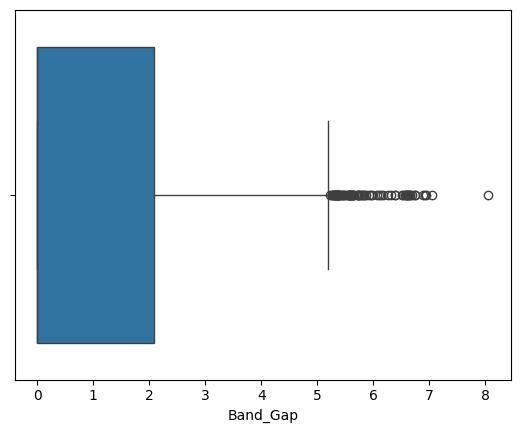

In [5]:
# 2. Visual Outlier Detection (Boxplot)
sns.boxplot(x=df['Band_Gap'])

In [7]:
# 3. Mathematical Outlier Detection (IQR Method)
Q1 = df['Band_Gap'].quantile(0.25)
Q3 = df['Band_Gap'].quantile(0.75)
IQR = Q3 - Q1

In [9]:
# Filter out the anomalies
outliers = df[(df['Band_Gap'] < (Q1 - 1.5 * IQR)) | (df['Band_Gap'] > (Q3 + 1.5 * IQR))]
print(f"Mathematical outliers detected: {len(outliers)}")

Mathematical outliers detected: 83
